In [ ]:
#a
"""
EXERCISE 6.9 (a) - THEORETICAL DERIVATION & MATRIX FORMULATION
======================================================================

1. SUBSTITUTING FOURIER SERIES INTO SCHRODINGER EQUATION:
---------------------------------------------------------
The time-independent Schrodinger equation is given by:
    H_hat * psi(x) = E * psi(x)

where the Hamiltonian operator H_hat is:
    H_hat = - (hbar^2 / 2M) * (d^2 / dx^2) + V(x)

We expand the wavefunction psi(x) in terms of a Fourier sine series:
    psi(x) = sum_{n=1}^{inf} [ psi_n * sin(n*pi*x / L) ]

Substituting this expansion into the Schrodinger equation:
    H_hat * sum_{n=1}^{inf} [ psi_n * sin(n*pi*x / L) ] = E * sum_{n=1}^{inf} [ psi_n * sin(n*pi*x / L) ]

Using the linearity of H_hat:
    sum_{n=1}^{inf} [ psi_n * H_hat * sin(n*pi*x / L) ] = E * sum_{n=1}^{inf} [ psi_n * sin(n*pi*x / L) ]


2. INNER PRODUCT AND ORTHOGONALITY RELATION:
--------------------------------------------
Multiply both sides by sin(m*pi*x / L) and integrate from x = 0 to x = L:

    sum_{n=1}^{inf} psi_n * integral_0^L [ sin(m*pi*x / L) * H_hat * sin(n*pi*x / L) ] dx 
    = E * sum_{n=1}^{inf} psi_n * integral_0^L [ sin(m*pi*x / L) * sin(n*pi*x / L) ] dx

Applying the orthogonality property of sine functions:
    integral_0^L [ sin(m*pi*x / L) * sin(n*pi*x / L) ] dx = L / 2   (if m = n)
                                                          = 0       (if m != n)

On the right-hand side, all terms vanish except when n = m:
    RHS = E * psi_m * (L / 2) = (1/2) * L * E * psi_m

This proves the required integrated equation:
    sum_{n=1}^{inf} psi_n * integral_0^L [ sin(m*pi*x / L) * H_hat * sin(n*pi*x / L) ] dx = (1/2) * L * E * psi_m


3. DEFINITION OF HAMILTONIAN MATRIX H AND EIGENVALUE FORM (H * psi = E * psi):
--------------------------------------------------------------------------------
Multiply both sides of the derived identity by (2 / L):

    sum_{n=1}^{inf} [ (2/L) * integral_0^L sin(m*pi*x / L) * H_hat * sin(n*pi*x / L) dx ] * psi_n = E * psi_m

By definition, the Hamiltonian matrix elements H_mn are:
    H_mn = (2/L) * integral_0^L sin(m*pi*x / L) * [ - (hbar^2 / 2M) * (d^2 / dx^2) + V(x) ] * sin(n*pi*x / L) dx

Substituting H_mn gives the component-wise matrix equation:
    sum_{n=1}^{inf} H_mn * psi_n = E * psi_m

In full matrix notation:
    [ H_11  H_12  H_13  ... ] [ psi_1 ]       [ psi_1 ]
    [ H_21  H_22  H_23  ... ] [ psi_2 ]  =  E [ psi_2 ]
    [ H_31  H_32  H_33  ... ] [ psi_3 ]       [ psi_3 ]
    [  ...   ...   ...  ... ] [  ...  ]       [  ...  ]

Which is the standard matrix eigenvalue equation:
    H * psi = E * psi
"""

In [5]:
#b
"""
EXERCISE 6.9 (b) - THEORETICAL DERIVATION, SYMMETRY PROOF & PYTHON IMPLEMENTATION
=================================================================================

1. ANALYTICAL EVALUATION OF HAMILTONIAN MATRIX ELEMENTS H_mn:
--------------------------------------------------------------
The Hamiltonian operator for V(x) = a * x / L is:
    H_hat = - (hbar^2 / 2M) * (d^2 / dx^2) + a * x / L

Applying H_hat to the basis function sin(n*pi*x / L):
    (d^2 / dx^2) sin(n*pi*x / L) = - (n*pi / L)^2 * sin(n*pi*x / L)

Therefore:
    H_hat * sin(n*pi*x / L) = [ (hbar^2 * n^2 * pi^2) / (2 * M * L^2) ] * sin(n*pi*x / L)
                              + (a * x / L) * sin(n*pi*x / L)

The matrix element H_mn is defined as:
    H_mn = (2 / L) * integral_0^L sin(m*pi*x / L) * H_hat * sin(n*pi*x / L) dx

We split H_mn into kinetic (K) and potential (V) contributions:
    H_mn = H_mn_K + H_mn_V


A. Kinetic Energy Contribution (H_mn_K):
   H_mn_K = (2 / L) * [ (hbar^2 * n^2 * pi^2) / (2 * M * L^2) ] * integral_0^L sin(m*pi*x / L) * sin(n*pi*x / L) dx

   Using orthogonality: integral_0^L sin(m*pi*x / L) * sin(n*pi*x / L) dx = (L / 2) * delta_mn
   
   H_mn_K = (hbar^2 * n^2 * pi^2) / (2 * M * L^2)    if m = n
          = 0                                         if m != n


B. Potential Energy Contribution (H_mn_V):
   H_mn_V = (2 * a / L^2) * integral_0^L x * sin(m*pi*x / L) * sin(n*pi*x / L) dx

   Using the provided integral identity:
   
   Case 1: m = n (Diagonal elements)
           integral_0^L x * sin^2(n*pi*x / L) dx = L^2 / 4
           H_nn_V = (2 * a / L^2) * (L^2 / 4) = a / 2

   Case 2: m != n and both m, n are EVEN or both ODD
           integral_0^L x * sin(m*pi*x / L) * sin(n*pi*x / L) dx = 0
           H_mn_V = 0

   Case 3: m != n and one is EVEN, one is ODD
           integral_0^L x * sin(m*pi*x / L) * sin(n*pi*x / L) dx = - (2*L / pi)^2 * [ m*n / (m^2 - n^2)^2 ]
           H_mn_V = - (8 * a / pi^2) * [ m*n / (m^2 - n^2)^2 ]


C. Final General Expression for H_mn:
   ---------------------------------
   1) For m = n:
      H_nn = [ (hbar^2 * n^2 * pi^2) / (2 * M * L^2) ] + (a / 2)

   2) For m != n and (m + n) is EVEN (both even or both odd):
      H_mn = 0

   3) For m != n and (m + n) is ODD (one even, one odd):
      H_mn = - (8 * a / pi^2) * [ m * n / (m^2 - n^2)^2 ]


2. PROOF THAT H IS REAL AND SYMMETRIC:
--------------------------------------
- Reality:
  All constants (hbar, M, L, a) and indices (m, n) are real numbers.
  Therefore, all matrix elements H_mn are purely real (H_mn in R).

- Symmetry (H_mn = H_nm):
  1) For m = n: H_nn = H_nn (Trivially symmetric).
  2) For m != n with same parity: H_mn = H_nm = 0 (Symmetric).
  3) For m != n with opposite parity:
     H_nm = - (8 * a / pi^2) * [ n * m / (n^2 - m^2)^2 ]
     Since n * m = m * n and (n^2 - m^2)^2 = (m^2 - n^2)^2:
     H_nm = - (8 * a / pi^2) * [ m * n / (m^2 - n^2)^2 ] = H_mn
  
  Hence, H_mn = H_nm for all m, n, proving the Hamiltonian matrix H is real and symmetric.
"""


import numpy as np

# parameters
M = 9.10e-31
e = 1.602e-19
L = 5e-10
a = 16e-19
hbar = 1.05e-34

def calculate_H(m,n):
    if m <= 0 or n <= 0:
        raise ValueError("Indices must be positive integers")
    if m == n:
        H_K = (hbar**2 * (n * np.pi)**2) / (2 * M * L**2)
        H_V = a / 2.0
        H_val = H_K + H_V

    elif (m + n) % 2 ==0:
        H_val = 0.0

    else:
        H_val = -(8.0 * a / (np.pi**2)) * ((m * n) / ((m**2 - n**2)**2))

    return H_val

# test
m = 1
n = 2
H_Joule = calculate_H(m,n)
print(H_Joule)


-2.88202477915983e-19


In [6]:
# c
N = 10
H = np.zeros((N,N))

for i in range(N):
    for j in range(N):
        m = i + 1
        n = j + 1
        H[i,j] = calculate_H(m,n)

# calculating eigenvalues of matrix(Energy)
eigenvalues_Joule = np.linalg.eigvalsh(H)

# Convert the results to eV and print the first 10 levels.
eigenvalues_eV = eigenvalues_Joule / e

print (eigenvalues_eV)


[  5.81600131  11.12991128  18.55545866  28.95737467  42.36632149
  58.77200681  78.16901828 100.55544841 125.92904557 154.41870852]


In [9]:
# d
N = 100
H = np.zeros((N,N))

for i in range(N):
    for j in range(N):
        m = i + 1
        n = j + 1
        H[i,j] = calculate_H(m,n)

# calculating eigenvalues of matrix(Energy)
eigenvalues_Joule = np.linalg.eigvalsh(H)

# Convert the results to eV and print the first 10 levels.
eigenvalues_eV = eigenvalues_Joule / e

print(eigenvalues_eV[:10])

[  5.8160009   11.12990995  18.55545678  28.95736582  42.36631231
  58.77195395  78.16896614 100.55481398 125.92820552 154.28843366]


<function matplotlib.pyplot.show(close=None, block=None)>

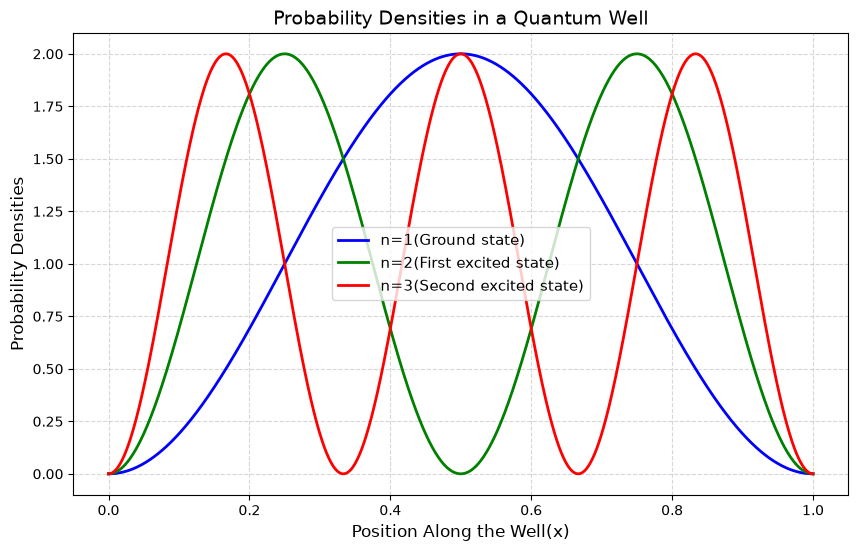

In [7]:
# e
import numpy as np
import pylab as plt
from scipy.integrate import trapezoid

# parameters
L = 1.0 # size of box
N = 1000 # number of point
x = np.linspace(0,L,N) 
dx = x[1] - x[0]
constant = np.sqrt(2/L) # normalization constant

# wavefunctions
psi_1 = constant * np.sin((1*np.pi*x)/L)  # Ground state
psi_2 = constant * np.sin((2*np.pi*x)/L)  # First excited state
psi_3 = constant * np.sin((3*np.pi*x)/L)  # Second excited state

# Probability
prob_1 = np.abs(psi_1)**2
prob_2 = np.abs(psi_2)**2
prob_3 = np.abs(psi_3)**2

# Numerical verification of the normalization condition
integral_1 = trapezoid(prob_1,dx=dx)
integral_2 = trapezoid(prob_2,dx=dx)
integral_3 = trapezoid(prob_3,dx=dx)


# graph
plt.figure(figsize=(10,6))

plt.plot(x,prob_1,label='n=1(Ground state)',color='blue',linewidth=2)
plt.plot(x,prob_2,label='n=2(First excited state)',color='green',linewidth=2)
plt.plot(x,prob_3,label='n=3(Second excited state)',color='red',linewidth=2)

plt.title('Probability Densities in a Quantum Well',fontsize=14)
plt.xlabel('Position Along the Well(x)',fontsize=12)
plt.ylabel('Probability Densities',fontsize=12)

plt.grid(True,linestyle='--',alpha=0.5)
plt.legend(fontsize=11)
plt.show

